# Temporal High-Rating Analysis

## Motivation

Our long-term goal is a binary classifier for whether a user assigns a **high rating** to a movie. The future classification target is:

$$
Y_{u,i,t} =
\mathbb{1}(\text{rating}_{u,i,t} \ge 4)
$$

Here, $u$ identifies the **user**, $i$ identifies the **movie (item)**, and $t$ is the **time of the rating event**. Therefore, $Y_{u,i,t}=1$ means that user $u$ gave movie $i$ a rating of at least 4 at time $t$; otherwise, $Y_{u,i,t}=0$.

We ultimately want to estimate:

$$
P(Y_{u,i,t}=1 \mid \mathcal{F}_{t^-})
$$

where $\mathcal{F}_{t^-}$ denotes information available **strictly before** the rating event at time $t$.

Before engineering features or fitting models, we need to understand whether users' **propensity to give high ratings** itself drifts over time. If generosity (or harshness) evolves within a user's history, then time-aware features may matter for the future classifier.

## Questions this notebook asks

1. Is the global high-rating rate stable over calendar time?
2. Is an individual user's tendency to give high ratings stable over their own rating history?
3. How large is the change between the early and late portions of a user's history?
4. Are apparent changes concentrated among low-activity users, or do they remain for users with substantial rating histories?
5. Is there enough evidence of temporal drift to justify time-aware features later?

## What this notebook is *not*

This notebook is **not** testing changes in movie taste or semantic preferences (genres, themes, tags, etc.). It only tests changes in the user's general propensity to assign ratings of 4 or higher.

## Temporal principle

Two related but different analyses appear below:

- **Calendar-time analysis**, $P(Y=1 \mid t)$, describes dataset-level behavior but can be driven by changing user composition.
- **Within-user chronological analysis** asks whether the *same* user's rating behavior evolves as their own history progresses.

The early-vs-late within-user analysis is the **primary** result of this notebook.


## Setup and data loading

We load `data/raw/rating.csv` with memory-conscious dtypes. The MovieLens 20M ratings file has ~20 million rows, so we avoid unnecessary object columns and do not print huge DataFrames.


In [93]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

DATA_PATH = Path("..") / "data" / "raw" / "rating.csv"

# Efficient dtypes for MovieLens 20M-scale ratings
DTYPES = {
    "userId": "int32",
    "movieId": "int32",
    "rating": "float32",
}

ratings = pd.read_csv(
    DATA_PATH,
    dtype=DTYPES,
    parse_dates=["timestamp"],
)

print(f"Loaded {len(ratings):,} rows from {DATA_PATH}")
print("Columns:", list(ratings.columns))
print("\nDtypes:")
print(ratings.dtypes)


Loaded 20,000,263 rows from ../data/raw/rating.csv
Columns: ['userId', 'movieId', 'rating', 'timestamp']

Dtypes:
userId                int32
movieId               int32
rating              float32
timestamp    datetime64[us]
dtype: object


## Data quality checks

Before analysis we verify scale, coverage, missingness, duplicates, the rating distribution, and approximate memory usage.


In [94]:
def summarize_ratings(df: pd.DataFrame) -> None:
    """Print compact quality checks without dumping the full frame."""
    n_rows = len(df)
    n_users = df["userId"].nunique()
    n_movies = df["movieId"].nunique()
    ts_min = df["timestamp"].min()
    ts_max = df["timestamp"].max()
    missing = df.isna().sum()
    n_dupes = int(df.duplicated().sum())
    mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

    print("=== Scale ===")
    print(f"Rows:            {n_rows:,}")
    print(f"Unique users:    {n_users:,}")
    print(f"Unique movies:   {n_movies:,}")
    print(f"Timestamp range: {ts_min}  →  {ts_max}")
    print(f"Approx. memory:  {mem_mb:.1f} MB")

    print("\n=== Missing values ===")
    print(missing.to_string())

    print("\n=== Duplicated rows ===")
    print(f"Exact duplicate rows: {n_dupes:,}")

    print("\n=== Rating distribution ===")
    rating_counts = df["rating"].value_counts().sort_index()
    rating_props = df["rating"].value_counts(normalize=True).sort_index()
    dist = pd.DataFrame({"count": rating_counts, "proportion": rating_props})
    print(dist.to_string(float_format=lambda x: f"{x:,.4f}"))


summarize_ratings(ratings)


=== Scale ===
Rows:            20,000,263
Unique users:    138,493
Unique movies:   26,744
Timestamp range: 1995-01-09 11:46:44  →  2015-03-31 06:40:02
Approx. memory:  381.5 MB

=== Missing values ===
userId       0
movieId      0
rating       0
timestamp    0

=== Duplicated rows ===
Exact duplicate rows: 0

=== Rating distribution ===
          count  proportion
rating                     
0.5      239125      0.0120
1.0      680732      0.0340
1.5      279252      0.0140
2.0     1430997      0.0715
2.5      883398      0.0442
3.0     4291193      0.2146
3.5     2200156      0.1100
4.0     5561926      0.2781
4.5     1534824      0.0767
5.0     2898660      0.1449


### Interpretation

The dataset contains 20,000,263 ratings from 138,493 users and 26,744 movies, covering January 1995 through March 2015. No missing values or exact duplicate rows were found, so no cleaning is required for these checks. The compact dtypes keep the in-memory table at approximately 381.5 MB.

Ratings are concentrated toward the upper-middle of the scale: 3.0 and 4.0 are the two most frequent values, while very low ratings are uncommon. This describes the rating scale, but the binary target must be checked separately because ratings below 4 include both 3.0 and 3.5.


## Binary target: high rating

Define:

```python
high_rating = 1 if rating >= 4 else 0
```


In [95]:
ratings["high_rating"] = (ratings["rating"] >= 4).astype("int8")

n_pos = int(ratings["high_rating"].sum())
n_neg = int((ratings["high_rating"] == 0).sum())
pos_rate = ratings["high_rating"].mean()

print(f"Positive ratings (rating >= 4): {n_pos:,}")
print(f"Negative ratings (rating < 4):  {n_neg:,}")
print(f"Overall positive class rate:    {pos_rate:.4f} ({100 * pos_rate:.2f}%)")


Positive ratings (rating >= 4): 9,995,410
Negative ratings (rating < 4):  10,004,853
Overall positive class rate:    0.4998 (49.98%)


### Interpretation

The target is almost perfectly balanced: 9,995,410 ratings (49.98%) are high ratings and 10,004,853 (50.02%) are below 4. Therefore, neither class is meaningfully dominant. For future modeling, a naive majority-class prediction would achieve only about 50.02% accuracy, although accuracy alone would still be an incomplete evaluation metric.


## Global temporal analysis

We first study:

$$
P(Y=1 \mid \text{calendar time})
$$

by aggregating ratings by year (and optionally by quarter).

**Important limitation:** changes in the global high-rating rate over calendar time can reflect *who* is rating (new users, churn, platform growth), not only changes within users. Do **not** interpret calendar-time shifts as within-user preference drift.


In [96]:
ratings["year"] = ratings["timestamp"].dt.year
ratings["year_quarter"] = ratings["timestamp"].dt.to_period("Q").astype(str)

yearly = (
    ratings.groupby("year", as_index=False)
    .agg(
        n_ratings=("high_rating", "size"),
        high_rating_rate=("high_rating", "mean"),
    )
)

quarterly = (
    ratings.groupby("year_quarter", as_index=False)
    .agg(
        n_ratings=("high_rating", "size"),
        high_rating_rate=("high_rating", "mean"),
    )
)

print("Ratings and high-rating rate by year:")
print(yearly.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))


Ratings and high-rating rate by year:
 year  n_ratings  high_rating_rate
 1995          4            0.5000
 1996    1612609            0.4886
 1997     700982            0.5172
 1998     308070            0.5441
 1999    1198384            0.5901
 2000    1953659            0.5740
 2001    1186125            0.5557
 2002     869719            0.5360
 2003    1035878            0.4814
 2004    1170049            0.4369
 2005    1803158            0.4385
 2006    1171836            0.4488
 2007    1053430            0.4532
 2008    1158777            0.4815
 2009     930036            0.4689
 2010     903691            0.4806
 2011     766366            0.4893
 2012     731389            0.5135
 2013     599327            0.5269
 2014     562888            0.5158
 2015     283886            0.4738


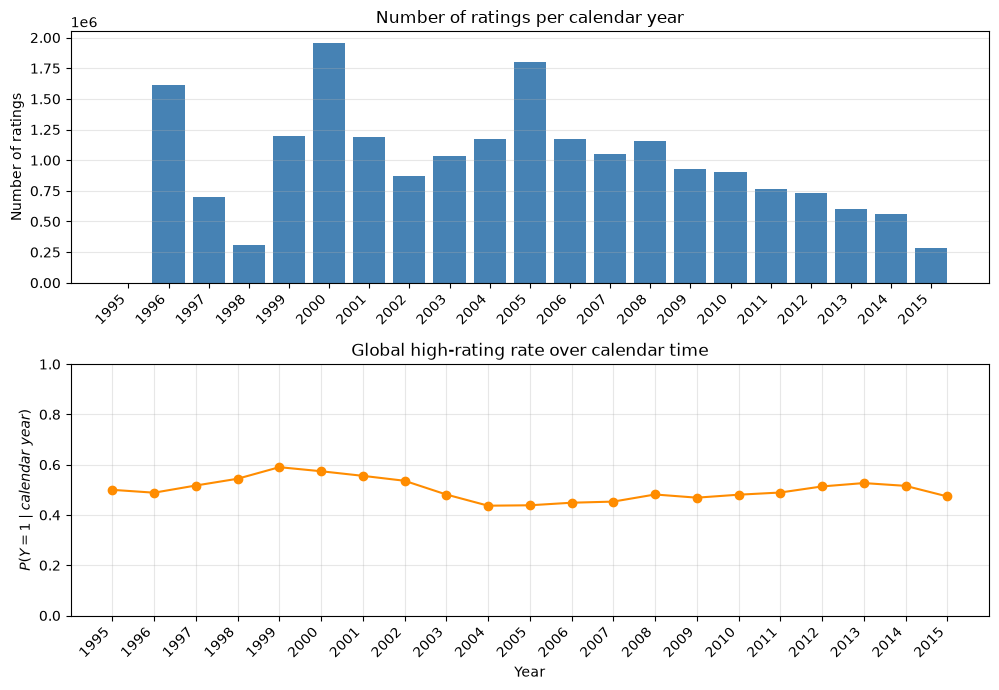

In [97]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

year_ticks = yearly["year"].astype(int).tolist()

axes[0].bar(year_ticks, yearly["n_ratings"], color="steelblue", width=0.8)
axes[0].set_ylabel("Number of ratings")
axes[0].set_title("Number of ratings per calendar year")
axes[0].set_xticks(year_ticks)
axes[0].set_xticklabels([str(y) for y in year_ticks], rotation=45, ha="right")
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(year_ticks, yearly["high_rating_rate"], marker="o", color="darkorange")
axes[1].set_xlabel("Year")
axes[1].set_ylabel(r"$P(Y=1 \mid calendar\ year)$")
axes[1].set_title("Global high-rating rate over calendar time")
axes[1].set_xticks(year_ticks)
axes[1].set_xticklabels([str(y) for y in year_ticks], rotation=45, ha="right")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()



### Interpretation (calendar time)

The aggregate high-rating rate is not stable across calendar years. Among years with substantial activity, it rises from 48.86% in 1996 to 59.01% in 1999, falls to 43.69% in 2004, and later recovers above 50% in several years. The observed annual range is 15.32 percentage points.

The endpoints require caution: 1995 contains only four ratings, and 2015 covers only the first three months. More importantly, this chart combines different users and movies in each year. The movement may reflect changing user composition, platform participation, or movie mix; it does not by itself demonstrate that the same users changed their behavior.


## User activity distribution: Number of ratings per user

Before early-vs-late comparisons, we study how many ratings each user contributes. Sparse histories make within-user rate differences extremely noisy.


In [98]:
user_counts = ratings.groupby("userId", sort=False).size().rename("n_ratings")

percentiles = [0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
labels = ["min", "25%", "median", "75%", "90%", "95%", "99%", "max"]
pct_values = user_counts.quantile(percentiles)

activity_summary = pd.DataFrame({"percentile": labels, "n_ratings": pct_values.values})
print("Distribution of ratings per user:")
print(activity_summary.to_string(index=False, float_format=lambda x: f"{x:,.1f}"))
print(f"\nMean ratings per user: {user_counts.mean():,.1f}")
print(f"Number of users:       {len(user_counts):,}")


Distribution of ratings per user:
percentile  n_ratings
       min       20.0
       25%       35.0
    median       68.0
       75%      155.0
       90%      334.0
       95%      520.0
       99%    1,113.1
       max    9,254.0

Mean ratings per user: 144.4
Number of users:       138,493


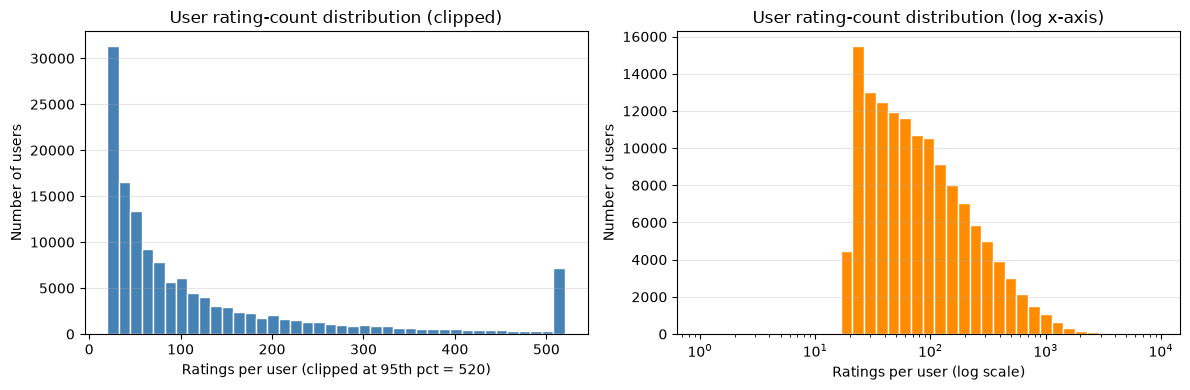

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear histogram with a capped x-axis for readability (long right tail)
cap = int(user_counts.quantile(0.95))
axes[0].hist(user_counts.clip(upper=cap), bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel(f"Ratings per user (clipped at 95th pct = {cap})")
axes[0].set_ylabel("Number of users")
axes[0].set_title("User rating-count distribution (clipped)")
axes[0].grid(axis="y", alpha=0.3)

# Log-scale histogram to show the full heavy tail
axes[1].hist(
    user_counts,
    bins=np.logspace(0, np.log10(user_counts.max()), 40),
    color="darkorange",
    edgecolor="white",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("Ratings per user (log scale)")
axes[1].set_ylabel("Number of users")
axes[1].set_title("User rating-count distribution (log x-axis)")
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()


### Why sparse users are unreliable for temporal drift

In this dataset every user has at least 20 ratings, so there are no ultra-sparse histories like 5–10 ratings. Still, users near that floor remain relatively noisy for early-vs-late comparisons: with ~20 total ratings, the early and late segments each contain only a handful of binary outcomes, so a large $\Delta_u$ can arise by chance. We therefore treat short histories cautiously and repeat the early-vs-late analysis under stricter minimum-history thresholds ($\ge 50$, $\ge 100$).


## Early-vs-late analysis (primary result)

For every user we:

1. Sort ratings chronologically (by `timestamp`, with `movieId` as a stable tie-break).
2. Assign a relative position within that user's history.
3. Segment into:
   - **early**: first 30% of ratings
   - **middle**: middle 40%
   - **late**: final 30%
4. Compute per-user early/late high-rating rates and

$$
\Delta_u = p_{u,\text{late}} - p_{u,\text{early}}
$$

### Boundary definition

Let $n_u$ be the number of ratings for user $u$, and let ranks be $0, 1, \ldots, n_u-1$ in chronological order. Define relative position $r = \text{rank} / n_u$. Then:

- early if $r < 0.3$
- late if $r \ge 0.7$
- middle otherwise

This is vectorized via `groupby` / `cumcount` — no Python loops over rows.


In [100]:
def compute_user_early_late(df: pd.DataFrame) -> pd.DataFrame:
    """Compute early/late high-rating rates per user with vectorized operations.

    Segments use relative chronological position within each user:
    early:  first 30%  (rank / n < 0.3)
    middle: next 40%
    late:   final 30%  (rank / n >= 0.7)
    """
    ordered = df.sort_values(["userId", "timestamp", "movieId"], kind="mergesort")
    rank = ordered.groupby("userId", sort=False).cumcount()
    n = ordered.groupby("userId", sort=False)["rating"].transform("size")
    rel_pos = rank / n

    ordered = ordered.assign(
        _segment=np.where(rel_pos < 0.3, "early", np.where(rel_pos >= 0.7, "late", "middle")),
    )

    early = ordered.loc[ordered["_segment"] == "early"]
    late = ordered.loc[ordered["_segment"] == "late"]

    early_stats = early.groupby("userId", sort=False).agg(
        n_early=("high_rating", "size"),
        early_high_rate=("high_rating", "mean"),
    )
    late_stats = late.groupby("userId", sort=False).agg(
        n_late=("high_rating", "size"),
        late_high_rate=("high_rating", "mean"),
    )

    totals = (
        ordered.groupby("userId", sort=False)
        .size()
        .rename("n_ratings")
        .to_frame()
    )

    user_stats = totals.join(early_stats, how="left").join(late_stats, how="left")
    user_stats["n_early"] = user_stats["n_early"].fillna(0).astype("int32")
    user_stats["n_late"] = user_stats["n_late"].fillna(0).astype("int32")
    user_stats["delta"] = user_stats["late_high_rate"] - user_stats["early_high_rate"]
    return user_stats


user_stats = compute_user_early_late(ratings)
print(f"Users with early/late stats: {len(user_stats):,}")
print(user_stats[["n_ratings", "n_early", "n_late", "early_high_rate", "late_high_rate", "delta"]].head())
print("\nOverall delta summary (all users with both segments):")
print(user_stats["delta"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())


Users with early/late stats: 138,493
        n_ratings  n_early  n_late  early_high_rate  late_high_rate     delta
userId                                                                       
1             175       53      52         0.339623        0.519231  0.179608
2              61       19      18         0.736842        0.611111 -0.125731
3             187       57      56         0.771930        0.625000 -0.146930
4              28        9       8         0.555556        0.625000  0.069444
5              66       20      19         0.550000        0.894737  0.344737

Overall delta summary (all users with both segments):
count    138493.000000
mean          0.033074
std           0.259606
min          -1.000000
10%          -0.277778
25%          -0.141667
50%           0.014286
75%           0.189394
90%           0.375000
max           1.000000


## Minimum-history filtering

We repeat the early-vs-late comparison for users with enough total ratings, and additionally require that early and late segments are not tiny. Sampling noise in $\hat p_{\text{late}} - \hat p_{\text{early}}$ shrinks as segment sizes grow.


In [101]:
def summarize_deltas(stats: pd.DataFrame, min_total: int, min_segment: int = 5) -> dict:
    """Summarize delta distribution for users meeting history thresholds."""
    mask = (
        (stats["n_ratings"] >= min_total)
        # Note: We require both early and late segments to be at least min_segment ratings (to exclude noisy users)
        & (stats["n_early"] >= min_segment)
        & (stats["n_late"] >= min_segment)
        & stats["delta"].notna()
    )
    d = stats.loc[mask, "delta"]
    if len(d) == 0:
        return {
            "min_total_ratings": min_total,
            "min_segment": min_segment,
            "n_users": 0,
            "mean_delta": np.nan,
            "median_delta": np.nan,
            "std_delta": np.nan,
            "p10": np.nan,
            "p25": np.nan,
            "p75": np.nan,
            "p90": np.nan,
            "pct_abs_ge_0.05": np.nan,
            "pct_abs_ge_0.10": np.nan,
            "pct_abs_ge_0.20": np.nan,
        }

    abs_d = d.abs()
    return {
        "min_total_ratings": min_total,
        "min_segment": min_segment,
        "n_users": int(len(d)),
        "mean_delta": float(d.mean()),
        "median_delta": float(d.median()),
        "std_delta": float(d.std(ddof=1)),
        "p10": float(d.quantile(0.10)),
        "p25": float(d.quantile(0.25)),
        "p75": float(d.quantile(0.75)),
        "p90": float(d.quantile(0.90)),
        "pct_abs_ge_0.05": float((abs_d >= 0.05).mean() * 100),
        "pct_abs_ge_0.10": float((abs_d >= 0.10).mean() * 100),
        "pct_abs_ge_0.20": float((abs_d >= 0.20).mean() * 100),
    }


THRESHOLDS = [20, 50, 100]
# For larger histories, require larger early/late segments so comparisons are meaningful
MIN_SEGMENT_BY_THRESHOLD = {20: 5, 50: 10, 100: 15}

threshold_rows = [
    summarize_deltas(user_stats, t, MIN_SEGMENT_BY_THRESHOLD[t]) for t in THRESHOLDS
]
threshold_summary = pd.DataFrame(threshold_rows)

print("Early-vs-late delta summary by minimum-history threshold")
print("(also requiring min early/late segment sizes as shown)\n")
display_cols = [
    "min_total_ratings",
    "min_segment",
    "n_users",
    "mean_delta",
    "median_delta",
    "std_delta",
    "p10",
    "p25",
    "p75",
    "p90",
    "pct_abs_ge_0.05",
    "pct_abs_ge_0.10",
    "pct_abs_ge_0.20",
]
print(threshold_summary[display_cols].to_string(index=False, float_format=lambda x: f"{x:,.4f}"))


Early-vs-late delta summary by minimum-history threshold
(also requiring min early/late segment sizes as shown)

 min_total_ratings  min_segment  n_users  mean_delta  median_delta  std_delta     p10     p25    p75    p90  pct_abs_ge_0.05  pct_abs_ge_0.10  pct_abs_ge_0.20
                20            5   138493      0.0331        0.0143     0.2596 -0.2778 -0.1417 0.1894 0.3750          82.9089          67.1377          40.8685
                50           10    85307     -0.0184       -0.0246     0.2163 -0.2846 -0.1612 0.1176 0.2593          80.7120          62.9397          34.3372
               100           15    52596     -0.0582       -0.0593     0.1941 -0.3008 -0.1839 0.0657 0.1857          79.3330          61.0997          31.4092


### Interpretation

Requiring longer histories reduces the dispersion of $\Delta_u$: its standard deviation falls from 0.260 for all users (at least 20 ratings) to 0.216 for users with at least 50 ratings and 0.194 for users with at least 100. The percentage with $|\Delta_u| \ge 0.20$ similarly falls from 40.9% to 34.3% and then 31.4%. This confirms that short histories amplify observed changes through sampling noise.

However, substantial differences remain after filtering. Among users with at least 100 ratings, 61.1% have $|\Delta_u| \ge 0.10$. The center also shifts from a small positive median (+0.014) for all users to a negative median (-0.059) in the 100-rating cohort. Thus, longer histories reduce noise but do not make early and late behavior identical. The negative shift is descriptive and may partly reflect how activity cohorts differ; it should not be interpreted causally.


## Visualizations

### A. Global high-rating rate (already shown above)

### B. User activity distribution (already shown above)

### C–E. Within-user drift views

We focus visualizations on users with a substantial history (default: $\ge 50$ total ratings and adequate early/late segments).


In [102]:
# Analysis cohort for visualizations C–E
VIZ_MIN_TOTAL = 50
VIZ_MIN_SEGMENT = MIN_SEGMENT_BY_THRESHOLD[VIZ_MIN_TOTAL]

viz_mask = (
    (user_stats["n_ratings"] >= VIZ_MIN_TOTAL)
    & (user_stats["n_early"] >= VIZ_MIN_SEGMENT)
    & (user_stats["n_late"] >= VIZ_MIN_SEGMENT)
    & user_stats["delta"].notna()
)
viz_users = user_stats.loc[viz_mask].copy()
print(
    f"Visualization cohort: {len(viz_users):,} users "
    f"(n_ratings >= {VIZ_MIN_TOTAL}, early/late >= {VIZ_MIN_SEGMENT})"
)


Visualization cohort: 85,307 users (n_ratings >= 50, early/late >= 10)


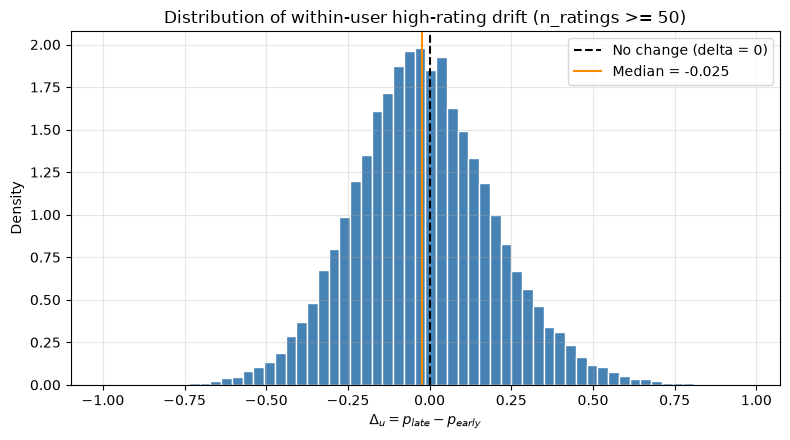

In [103]:
# C. Distribution of delta_u
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(viz_users["delta"], bins=60, color="steelblue", edgecolor="white", density=True)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="No change (delta = 0)")
ax.axvline(
    viz_users["delta"].median(),
    color="darkorange",
    linestyle="-",
    linewidth=1.5,
    label=f"Median = {viz_users['delta'].median():.3f}",
)
ax.set_xlabel(r"$\Delta_u = p_{late} - p_{early}$")
ax.set_ylabel("Density")
ax.set_title(f"Distribution of within-user high-rating drift (n_ratings >= {VIZ_MIN_TOTAL})")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


### Interpretation (delta distribution)

For the 85,307 users with at least 50 ratings and adequate segment sizes, the distribution is broad and centered slightly below zero: mean $\Delta_u=-0.018$ and median $\Delta_u=-0.025$. This indicates a small average decrease in high-rating propensity, not a large universal shift. At the same time, the standard deviation is 0.216 and 62.9% of users have $|\Delta_u| \ge 0.10$, showing considerable variation between users. The aggregate center and the individual spread therefore tell different parts of the story.

**Finding:** Active users show a modest but consistent tendency to assign fewer high ratings in the later portion of their histories. The median decrease is about 2.5 percentage points among users with at least 50 ratings and 5.9 percentage points among users with at least 100 ratings. Given the large number of users, this shift would likely be distinguishable from zero under simple statistical assumptions, but no formal inference is performed here. It is preliminary temporal signal—not proof that users psychologically become more demanding—because selection effects, concentrated rating sessions, and changes in the available movie mix may also contribute.


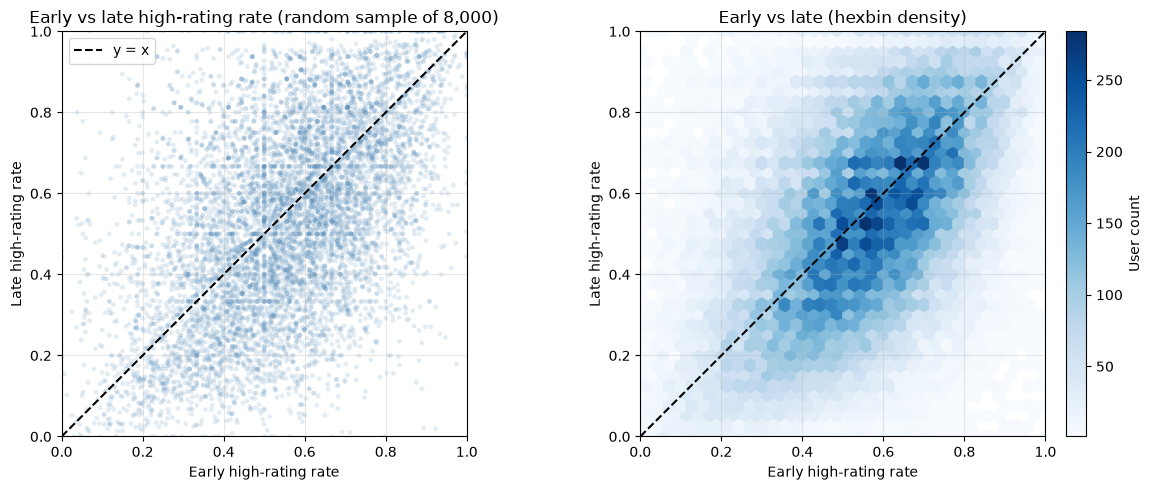

In [104]:
# D. Early vs late scatter (sample to avoid overplotting)
MAX_SCATTER_POINTS = 8_000
if len(viz_users) > MAX_SCATTER_POINTS:
    scatter_df = viz_users.sample(MAX_SCATTER_POINTS, random_state=RANDOM_SEED)
    sample_note = f"random sample of {MAX_SCATTER_POINTS:,}"
else:
    scatter_df = viz_users
    sample_note = f"all {len(viz_users):,}"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    scatter_df["early_high_rate"],
    scatter_df["late_high_rate"],
    alpha=0.15,
    s=12,
    c="steelblue",
    edgecolors="none",
)
axes[0].plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1.5, label="y = x")
axes[0].set_xlabel("Early high-rating rate")
axes[0].set_ylabel("Late high-rating rate")
axes[0].set_title(f"Early vs late high-rating rate ({sample_note})")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect("equal")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3)

hb = axes[1].hexbin(
    viz_users["early_high_rate"],
    viz_users["late_high_rate"],
    gridsize=35,
    cmap="Blues",
    mincnt=1,
    extent=(0, 1, 0, 1),
)
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Early high-rating rate")
axes[1].set_ylabel("Late high-rating rate")
axes[1].set_title("Early vs late (hexbin density)")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect("equal")
cb = fig.colorbar(hb, ax=axes[1], fraction=0.046, pad=0.04)
cb.set_label("User count")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


### Interpretation (early vs late scatter)

Users are distributed on both sides of the $y=x$ line, so the data do not support one common direction of change for everyone. The slight negative median reported above is consistent with somewhat more mass below the diagonal, while the broad dispersion shows strong user-level heterogeneity. The dense areas are more informative than isolated extreme points, which may still reflect sampling variation or unusual rating histories.


activity_bin  n_users  mean_abs_delta  median_abs_delta
       20-49    53186          0.2535            0.2121
       50-99    32711          0.1885            0.1563
     100-199    25770          0.1583            0.1328
     200-499    19335          0.1581            0.1315
     500-999     5597          0.1699            0.1440
       1000+     1894          0.1661            0.1424


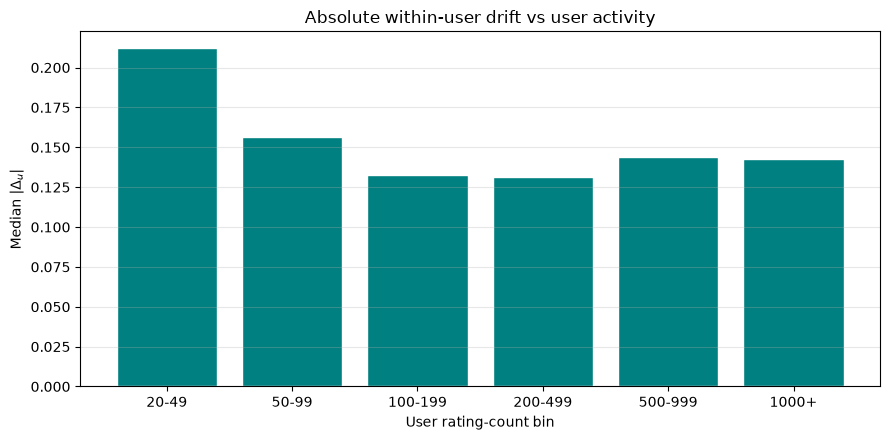

In [105]:
# E. |delta| vs user activity
activity_bins = [0, 20, 50, 100, 200, 500, 1000, np.inf]
activity_labels = ["1-19", "20-49", "50-99", "100-199", "200-499", "500-999", "1000+"]

drift_activity = user_stats.loc[
    user_stats["delta"].notna()
    & (user_stats["n_early"] >= 3)
    & (user_stats["n_late"] >= 3)
].copy()
drift_activity["abs_delta"] = drift_activity["delta"].abs()
drift_activity["activity_bin"] = pd.cut(
    drift_activity["n_ratings"],
    bins=activity_bins,
    labels=activity_labels,
    right=False,
)

bin_summary = (
    drift_activity.groupby("activity_bin", observed=True)
    .agg(
        n_users=("abs_delta", "size"),
        mean_abs_delta=("abs_delta", "mean"),
        median_abs_delta=("abs_delta", "median"),
    )
    .reset_index()
)
print(bin_summary.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(
    bin_summary["activity_bin"].astype(str),
    bin_summary["median_abs_delta"],
    color="teal",
    edgecolor="white",
)
ax.set_xlabel("User rating-count bin")
ax.set_ylabel(r"Median $|\Delta_u|$")
ax.set_title("Absolute within-user drift vs user activity")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


### Interpretation (activity vs absolute drift)

Median absolute drift falls from 0.212 for users with 20–49 ratings to 0.156 for 50–99 and 0.133 for 100–199 ratings. This strong initial decline is consistent with sampling noise being larger in shorter histories. Beyond roughly 100–200 ratings, however, median $|\Delta_u|$ levels off near 0.13–0.14 rather than continuing toward zero. Sample size therefore explains part, but not all, of the observed early-vs-late differences.


## Illustrative individual users

The following users are **illustrative examples** chosen after computing $\Delta_u$ among users with substantial histories. They are not a statistical sample and should not be treated as representative evidence by themselves; they only make the aggregate patterns easier to visualize.

We plot a rolling high-rating rate in **rating-event order** (not calendar days), using a window of 50 ratings.


Illustrative users (userId → role):
  stable (near-zero delta): userId=4374, n=230, early=0.754, late=0.754, delta=0.000
  substantial increase: userId=53622, n=251, early=0.026, late=1.000, delta=0.974
  substantial decrease: userId=75173, n=953, early=0.976, late=0.039, delta=-0.937


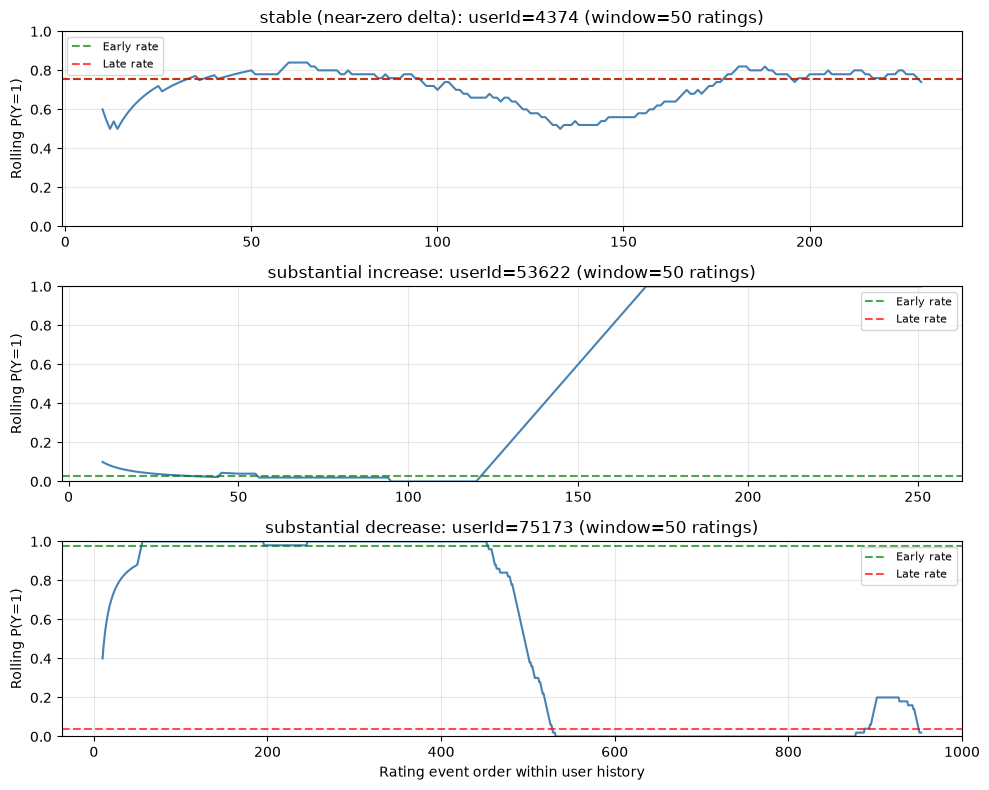

In [106]:
def rolling_high_rate_series(user_id: int, window: int = 50) -> pd.Series:
    """Rolling mean of high_rating in chronological event order for one user."""
    user_df = (
        ratings.loc[ratings["userId"] == user_id, ["timestamp", "movieId", "high_rating"]]
        .sort_values(["timestamp", "movieId"], kind="mergesort")
        .reset_index(drop=True)
    )
    return user_df["high_rating"].rolling(
        window=window, min_periods=max(10, window // 5)
    ).mean()


def pick_example_users(
    stats: pd.DataFrame, min_total: int = 200, min_segment: int = 40
) -> dict:
    """Select stable / increasing / decreasing examples among long-history users."""
    pool = stats.loc[
        (stats["n_ratings"] >= min_total)
        & (stats["n_early"] >= min_segment)
        & (stats["n_late"] >= min_segment)
        & stats["delta"].notna()
    ].copy()
    pool["abs_delta"] = pool["delta"].abs()

    stable = pool.loc[pool["abs_delta"].idxmin()]
    increasing = pool.loc[pool["delta"].idxmax()]
    decreasing = pool.loc[pool["delta"].idxmin()]

    return {
        "stable (near-zero delta)": int(stable.name),
        "substantial increase": int(increasing.name),
        "substantial decrease": int(decreasing.name),
    }


example_users = pick_example_users(user_stats)
print("Illustrative users (userId → role):")
for role, uid in example_users.items():
    row = user_stats.loc[uid]
    print(
        f"  {role}: userId={uid}, n={int(row['n_ratings'])}, "
        f"early={row['early_high_rate']:.3f}, late={row['late_high_rate']:.3f}, "
        f"delta={row['delta']:.3f}"
    )

ROLLING_WINDOW = 50
fig, axes = plt.subplots(len(example_users), 1, figsize=(10, 8), sharex=False)
if len(example_users) == 1:
    axes = [axes]

for ax, (role, uid) in zip(axes, example_users.items()):
    series = rolling_high_rate_series(uid, window=ROLLING_WINDOW)
    ax.plot(series.index + 1, series.values, color="steelblue", linewidth=1.5)
    ax.axhline(
        user_stats.loc[uid, "early_high_rate"],
        color="green",
        linestyle="--",
        alpha=0.7,
        label="Early rate",
    )
    ax.axhline(
        user_stats.loc[uid, "late_high_rate"],
        color="red",
        linestyle="--",
        alpha=0.7,
        label="Late rate",
    )
    ax.set_ylabel("Rolling P(Y=1)")
    ax.set_title(f"{role}: userId={uid} (window={ROLLING_WINDOW} ratings)")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)

axes[-1].set_xlabel("Rating event order within user history")
fig.tight_layout()
plt.show()


## Statistical caution

The observed difference

$$
\hat p_{\text{late}} - \hat p_{\text{early}}
$$

combines possible behavioral change with sampling noise. MovieLens 20M contains no users with fewer than 20 ratings, but a user at that minimum contributes only about six observations to each 30% segment. A few binary outcomes can therefore move either estimated rate substantially. The same observed difference is more credible for a user with hundreds of ratings.

The decreasing dispersion across activity thresholds confirms that sample size matters. Nevertheless, the remaining variation among long-history users should not automatically be labeled true behavioral drift: selection effects, concentrated rating sessions, and other unmeasured temporal factors may also contribute. The present analysis is descriptive; formal uncertainty estimates and predictive validation are intentionally left for later work.


# Conclusions and Next Steps

The cell below answers each research question using quantities computed earlier in this notebook. Re-run the notebook end-to-end so these conclusions stay consistent with the loaded data.


In [107]:
# Gather key numbers for conclusions
yearly_rate_range = yearly["high_rating_rate"].max() - yearly["high_rating_rate"].min()
yearly_rate_std = yearly["high_rating_rate"].std(ddof=1)

main = threshold_summary.loc[threshold_summary["min_total_ratings"] == 50].iloc[0]
strict = threshold_summary.loc[threshold_summary["min_total_ratings"] == 100].iloc[0]
loose = threshold_summary.loc[threshold_summary["min_total_ratings"] == 20].iloc[0]

low_bins = drift_activity.loc[
    drift_activity["activity_bin"].isin(["1-19", "20-49"]), "abs_delta"
]
high_bins = drift_activity.loc[
    drift_activity["activity_bin"].isin(["200-499", "500-999", "1000+"]), "abs_delta"
]

print("=== Q1: Calendar-time stability ===")
print(
    f"Yearly high-rating rate min/max: "
    f"{yearly['high_rating_rate'].min():.4f} / {yearly['high_rating_rate'].max():.4f}"
)
print(f"Yearly range (max-min):          {yearly_rate_range:.4f}")
print(f"Yearly std:                      {yearly_rate_std:.4f}")
if yearly_rate_range < 0.03:
    q1 = "Relatively stable: yearly high-rating rates move only slightly."
elif yearly_rate_range < 0.08:
    q1 = "Moderately unstable: noticeable year-to-year movement exists."
else:
    q1 = "Materially unstable: sizable calendar-time swings in P(Y=1)."
print("Answer:", q1)
print(
    "Caveat: calendar-time changes can reflect user composition, not within-user drift."
)

print("\n=== Q2: Within-user delta (n_ratings >= 50) ===")
print(f"Users:           {int(main['n_users']):,}")
print(f"Mean delta:      {main['mean_delta']:+.4f}")
print(f"Median delta:    {main['median_delta']:+.4f}")
print(f"Std delta:       {main['std_delta']:.4f}")
print(f"|delta|>=0.05:   {main['pct_abs_ge_0.05']:.1f}%")
print(f"|delta|>=0.10:   {main['pct_abs_ge_0.10']:.1f}%")
print(f"|delta|>=0.20:   {main['pct_abs_ge_0.20']:.1f}%")
print(
    "Answer: average within-user change is near "
    f"{main['median_delta']:+.3f}, while "
    f"{main['pct_abs_ge_0.10']:.1f}% of these users shift by at least 0.10."
)

print("\n=== Q3: Does drift shrink with longer histories? ===")
for _, row in threshold_summary.iterrows():
    print(
        f"  >= {int(row['min_total_ratings']):>3} ratings: "
        f"median delta={row['median_delta']:+.4f}, "
        f"std={row['std_delta']:.4f}, "
        f"|d|>=0.10: {row['pct_abs_ge_0.10']:.1f}%"
    )
if len(low_bins) and len(high_bins):
    print(f"  Median |delta| in low-activity bins:  {low_bins.median():.4f}")
    print(f"  Median |delta| in high-activity bins: {high_bins.median():.4f}")
    q3 = (
        "Partly: absolute drift falls sharply through roughly 100-200 ratings, "
        "showing that short histories add sampling noise. It then stabilizes "
        "near 0.13-0.14, so sample size does not explain all remaining variation."
    )
    print("Answer:", q3)

print("\n=== Q4: Evidence for time-aware features? ===")
evidence_bits = []
if yearly_rate_range >= 0.03:
    evidence_bits.append("calendar-time high-rating rates are not flat")
if main["pct_abs_ge_0.10"] >= 25:
    evidence_bits.append(
        "a sizable share of longer-history users still show |delta| >= 0.10"
    )
if abs(main["mean_delta"]) >= 0.02:
    evidence_bits.append("the mean within-user delta is away from zero")
if evidence_bits:
    print("Preliminary yes — supporting signals:")
    for bit in evidence_bits:
        print(" -", bit)
    print(
        "Even if the average user is nearly stable, heterogeneous personal drift "
        "can still motivate time-aware user features later."
    )
else:
    print(
        "Weak so far for generosity drift alone; still worth checking genre-level "
        "temporal preference changes before discarding time-aware features."
    )

print("\n=== Q5: Next analysis ===")
print(
    "Genre Preference Drift: test whether users' genre preferences change over "
    "time, rather than only whether they become more/less generous raters."
)


=== Q1: Calendar-time stability ===
Yearly high-rating rate min/max: 0.4369 / 0.5901
Yearly range (max-min):          0.1532
Yearly std:                      0.0430
Answer: Materially unstable: sizable calendar-time swings in P(Y=1).
Caveat: calendar-time changes can reflect user composition, not within-user drift.

=== Q2: Within-user delta (n_ratings >= 50) ===
Users:           85,307
Mean delta:      -0.0184
Median delta:    -0.0246
Std delta:       0.2163
|delta|>=0.05:   80.7%
|delta|>=0.10:   62.9%
|delta|>=0.20:   34.3%
Answer: average within-user change is near -0.025, while 62.9% of these users shift by at least 0.10.

=== Q3: Does drift shrink with longer histories? ===
  >=  20 ratings: median delta=+0.0143, std=0.2596, |d|>=0.10: 67.1%
  >=  50 ratings: median delta=-0.0246, std=0.2163, |d|>=0.10: 62.9%
  >= 100 ratings: median delta=-0.0593, std=0.1941, |d|>=0.10: 61.1%
  Median |delta| in low-activity bins:  0.2121
  Median |delta| in high-activity bins: 0.1347
Answer: Pa

### Q1. Is the aggregate high-rating rate stable over calendar time?

**No.** Excluding the nearly empty 1995 endpoint from interpretation, the annual high-rating rate still moves materially: it reaches 59.01% in 1999, falls to 43.69% in 2004, and later recovers above 50% in several years. This is evidence of dataset-level temporal variation, not proof of within-user change, because the users and movies represented each year also change.

### Q2. How much does high-rating propensity change within users?

The average change is modest, but individual differences are large. For users with at least 50 ratings, mean $\Delta_u=-0.018$ and median $\Delta_u=-0.025$, suggesting a small average decline in high-rating propensity. However, 62.9% change by at least 0.10 in either direction and 34.3% change by at least 0.20. A near-zero average therefore does not imply that every user is stable.

### Q3. Does the apparent drift decrease when restricting to users with longer histories?

**Partly.** The standard deviation of $\Delta_u$ declines from 0.260 at the 20-rating threshold to 0.194 at the 100-rating threshold, and median $|\Delta_u|$ falls sharply between the 20–49 and 100–199 activity bins. This confirms that short histories inflate apparent drift. Beyond approximately 100–200 ratings, median absolute drift stabilizes around 0.13–0.14, so sampling noise alone does not explain all observed variation.

### Q4. Is there preliminary evidence that temporal information may matter for our future classifier?

**Yes, provisionally.** Calendar rates are not flat, and substantial within-user differences remain among users with long histories. These findings justify investigating time-aware information later. They do not yet show that temporal features improve out-of-sample prediction; that must be tested using only information available strictly before each rating event.

### Q5. What analysis should come next?

The recommended next step is **Genre Preference Drift**: determine whether users' relative preferences for genres evolve through their histories, separately from becoming generally more or less generous raters. That analysis should preserve chronological ordering and the $\mathcal{F}_{t^-}$ constraint, but it is outside the scope of this notebook.
